<center>
<img src="img/logo-hds.png" width="650"/>

***

<center>Lecture 1</center>

***

<center>Introduction<br> + <br>Python Data Science Toolkit</center>  

***

<center>7 September 2026<center>
<center>Rahman Peimankar<center>

# Today's plan

| Part | Time | Focus |
|---|---:|---|
| Lecture A | 45 min | Jupyter + NumPy + physiological time series |
| Lecture B | 45 min | pandas + Matplotlib + Python ecosystem |
| Exercise 1 | 30 min | NumPy and signal slicing |
| Exercise 2 | 20–25 min | pandas and visualisation |
| GitHub setup | 5–10 min | Create first group repository |

### Success today
You can inspect, manipulate and visualise simple health data in Python.

# Why start with Python basics?

Before using real ECG, EEG, EDA, accelerometry or PhysioNet data, we need to answer basic questions:

- How is a signal represented in Python?
- What is the shape of the data?
- What does one row or one column mean?
- How do we select a time interval?
- How do we calculate simple summaries?
- How do we make a clear figure?
- How do we save our work reproducibly?

These are the foundations for the rest of the course.

# The first data-science workflow: inspect → select → summarise → visualise

<center>
<img src="img/image-1.png" width="1050"/>
<center>  

# Learning objectives

By the end of this lecture, you should be able to:

- use Jupyter notebooks for code and explanations;
- explain the difference between a NumPy array and a pandas DataFrame;
- create and inspect one-dimensional arrays;
- use sampling frequency to create a time axis;
- slice a physiological signal by time;
- inspect and filter a tabular health dataset;
- create simple plots using Matplotlib;
- create the first GitHub repository for your group project.

# Jupyter Notebook

A notebook contains two main cell types:

### Markdown cells
Used for headings, explanations, equations and interpretation.

### Code cells
Used for Python code and output.

Good notebooks are not only code.

They should tell a story:

**question → data → code → result → interpretation**

In [2]:
# Standard imports for today's lecture

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)

NumPy version: 2.4.2
pandas version: 3.0.0


# The Python health-data-science ecosystem

<center>
<img src="img/image-2.png" width="1050"/>
<center>  

# NumPy: numerical arrays

A NumPy array is useful when data are mostly numerical.

Examples:

- ECG signal samples;
- accelerometer x, y, z measurements;
- EEG channel values;
- feature matrices;
- model input data.

For a simple signal, we often start with:

```python
signal = np.array([...])
```

The most important first question is:

```python
signal.shape
```

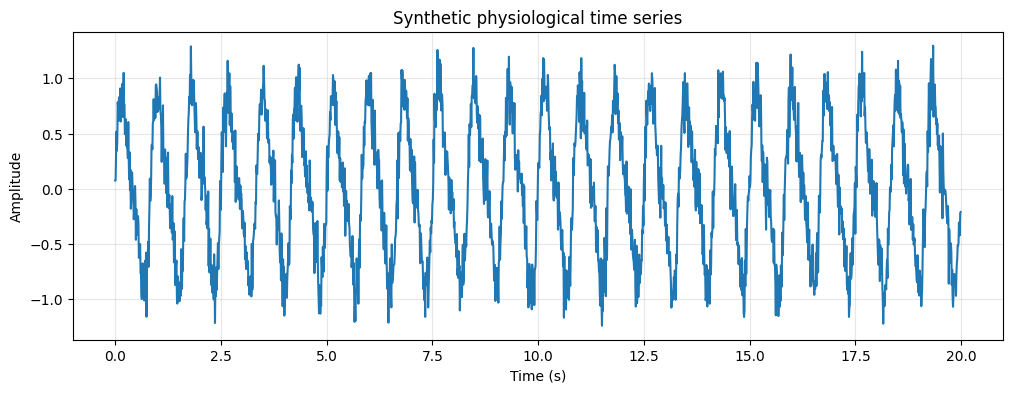

In [4]:
# Create a synthetic physiological signal

np.random.seed(42)

fs = 100          # sampling frequency in Hz
duration = 20     # seconds

time = np.arange(0, duration, 1/fs)

signal = (
    0.8 * np.sin(2 * np.pi * 1.2 * time)
    + 0.25 * np.sin(2 * np.pi * 2.4 * time)
    + 0.15 * np.random.randn(len(time))
)

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Synthetic physiological time series")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# Inspect the NumPy array

print("Number of samples:", len(signal))
print("Shape:", signal.shape)
print("Data type:", signal.dtype)
print("Minimum:", signal.min())
print("Maximum:", signal.max())
print("Mean:", signal.mean())
print("Standard deviation:", signal.std())

Number of samples: 2000
Shape: (2000,)
Data type: float64
Minimum: -1.2387327749578358
Maximum: 1.2948626135281165
Mean: 0.006762621980361076
Standard deviation: 0.6076204975175279


# Sampling frequency and time

If a signal is sampled at:

\[
f_s = 100 \text{ Hz}
\]

then 100 samples are recorded every second.

A 20-second signal contains:

\[
20 \times 100 = 2000 \text{ samples}
\]

To convert sample index to time:

\[
\text{time} = \frac{\text{sample index}}{f_s}
\]

# Indexing and slicing

Python indexing starts at zero.

```python
signal[0]       # first sample
signal[10]      # 11th sample
signal[0:100]   # first 100 samples
```

For time-series data, slicing is often used to extract a time interval.

Example:

```python
start = 5 * fs
stop = 10 * fs
signal_5_10 = signal[start:stop]
```

Start index: 500
Stop index: 1000
Number of samples: 500


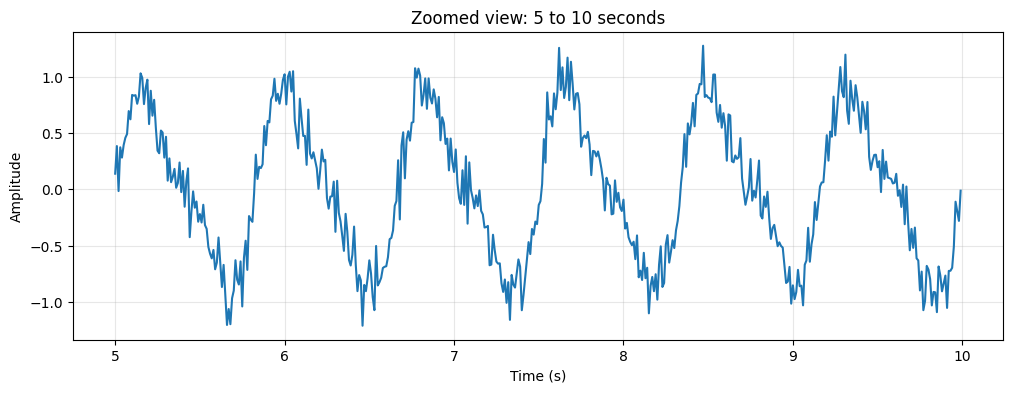

In [6]:
# Extract the interval from 5 to 10 seconds

start = 5 * fs
stop = 10 * fs

signal_5_10 = signal[start:stop]
time_5_10 = time[start:stop]

print("Start index:", start)
print("Stop index:", stop)
print("Number of samples:", len(signal_5_10))

plt.figure(figsize=(12, 4))
plt.plot(time_5_10, signal_5_10)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Zoomed view: 5 to 10 seconds")
plt.grid(alpha=0.3)
plt.show()

Number of samples above threshold: 233
Percentage of signal above threshold: 11.65


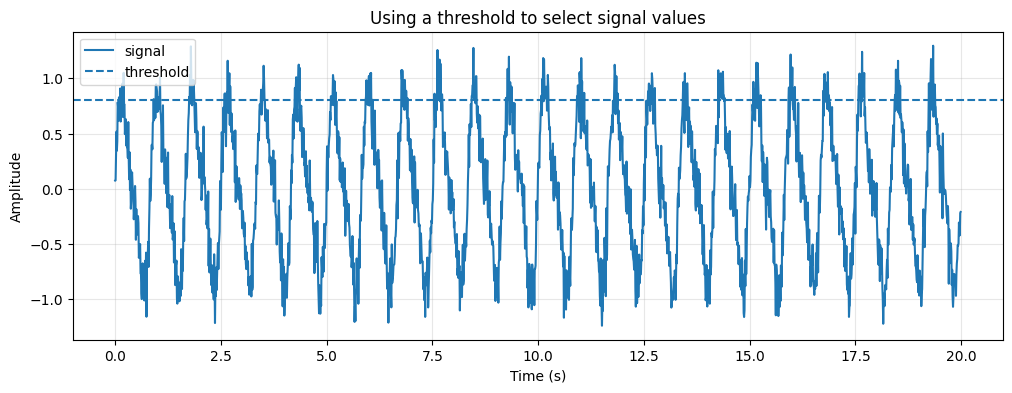

In [7]:
# Boolean indexing: select values above a threshold

threshold = 0.8
high_values = signal[signal > threshold]

print("Number of samples above threshold:", len(high_values))
print("Percentage of signal above threshold:", 100 * len(high_values) / len(signal))

plt.figure(figsize=(12, 4))
plt.plot(time, signal, label="signal")
plt.axhline(threshold, linestyle="--", label="threshold")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Using a threshold to select signal values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

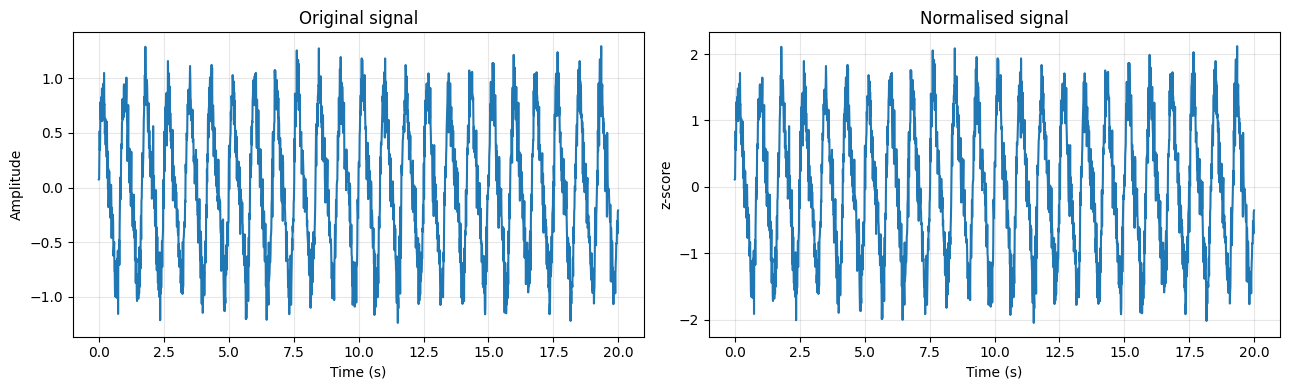

In [8]:
# Vectorised operations: no explicit loop needed

normalised_signal = (signal - signal.mean()) / signal.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(time, signal)
axes[0].set_title("Original signal")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].plot(time, normalised_signal)
axes[1].set_title("Normalised signal")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("z-score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quick check — NumPy

Discuss briefly:

1. What is the difference between `len(signal)` and `signal.shape`?
2. How many samples are in 3 seconds if `fs = 250` Hz?
3. Why do we create a `time` array before plotting?
4. Why might we plot only 5 seconds instead of a full 30-minute recording?

# pandas: tabular health data

A pandas DataFrame is useful for labelled tables.

Examples:

- participant metadata;
- clinical variables;
- extracted signal features;
- model predictions;
- evaluation results.

A DataFrame has:

- rows;
- columns;
- column names;
- data types;
- indexes.

In health data science, one of the most important questions is:

## What does one row represent?

In [9]:
# Create a small wearable-health DataFrame

data = {
    "participant_id": ["P01", "P02", "P03", "P04", "P05",
                       "P06", "P07", "P08", "P09", "P10"],
    "age": [24, 31, 28, 45, 52, 37, 41, 29, 34, 48],
    "sex": ["F", "M", "F", "M", "F", "M", "F", "M", "F", "M"],
    "activity": ["Walking", "Rest", "Running", "Walking", "Rest",
                 "Running", "Walking", "Rest", "Running", "Walking"],
    "heart_rate": [96, 68, 145, 101, 72, 152, 92, 65, 148, 105],
    "steps": [1850, 120, 3240, 2010, 90, 3560, 1760, 150, 3380, 2200],
    "recording_minutes": [28, 30, 25, 30, 29, 24, 30, 27, 26, 30],
    "signal_quality": [0.95, 0.98, 0.82, 0.91, 0.97,
                       0.76, 0.94, 0.96, 0.79, 0.89]
}

df = pd.DataFrame(data)
df

,participant_id,age,sex,activity,heart_rate,steps,recording_minutes,signal_quality
0,P01,24,F,Walking,96,1850,28,0.95
1,P02,31,M,Rest,68,120,30,0.98
2,P03,28,F,Running,145,3240,25,0.82
3,P04,45,M,Walking,101,2010,30,0.91
4,P05,52,F,Rest,72,90,29,0.97
5,P06,37,M,Running,152,3560,24,0.76
6,P07,41,F,Walking,92,1760,30,0.94
7,P08,29,M,Rest,65,150,27,0.96
8,P09,34,F,Running,148,3380,26,0.79
9,P10,48,M,Walking,105,2200,30,0.89


In [10]:
# Inspect the DataFrame

display(df.head())

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nNumerical summary:")
display(df.describe())

,participant_id,age,sex,activity,heart_rate,steps,recording_minutes,signal_quality
0,P01,24,F,Walking,96,1850,28,0.95
1,P02,31,M,Rest,68,120,30,0.98
2,P03,28,F,Running,145,3240,25,0.82
3,P04,45,M,Walking,101,2010,30,0.91
4,P05,52,F,Rest,72,90,29,0.97


Shape: (10, 8)

Columns:
['participant_id', 'age', 'sex', 'activity', 'heart_rate', 'steps', 'recording_minutes', 'signal_quality']

Data types:
participant_id           str
age                    int64
sex                      str
activity                 str
heart_rate             int64
steps                  int64
recording_minutes      int64
signal_quality       float64
dtype: object

Missing values:
participant_id       0
age                  0
sex                  0
activity             0
heart_rate           0
steps                0
recording_minutes    0
signal_quality       0
dtype: int64

Numerical summary:


,age,heart_rate,steps,recording_minutes,signal_quality
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,36.900000,104.400000,1836.000000,27.900000,0.897000
std,9.338689,33.297314,1347.089043,2.282786,0.079729
min,24.000000,65.000000,90.000000,24.000000,0.760000
25%,29.500000,77.000000,552.500000,26.250000,0.837500
50%,35.500000,98.500000,1930.000000,28.500000,0.925000
75%,44.000000,135.000000,2980.000000,30.000000,0.957500
max,52.000000,152.000000,3560.000000,30.000000,0.980000


In [11]:
# Select columns

display(df["heart_rate"])

display(df[["participant_id", "activity", "heart_rate"]])

0     96
1     68
2    145
3    101
4     72
5    152
6     92
7     65
8    148
9    105
Name: heart_rate, dtype: int64

,participant_id,activity,heart_rate
0,P01,Walking,96
1,P02,Rest,68
2,P03,Running,145
3,P04,Walking,101
4,P05,Rest,72
5,P06,Running,152
6,P07,Walking,92
7,P08,Rest,65
8,P09,Running,148
9,P10,Walking,105


In [12]:
# Filter rows

high_hr = df[df["heart_rate"] > 100]
running = df[df["activity"] == "Running"]
low_quality = df[df["signal_quality"] < 0.85]

print("Participants with heart rate > 100:")
display(high_hr)

print("Running participants:")
display(running)

print("Low-quality recordings:")
display(low_quality)

Participants with heart rate > 100:


,participant_id,age,sex,activity,heart_rate,steps,recording_minutes,signal_quality
2,P03,28,F,Running,145,3240,25,0.82
3,P04,45,M,Walking,101,2010,30,0.91
5,P06,37,M,Running,152,3560,24,0.76
8,P09,34,F,Running,148,3380,26,0.79
9,P10,48,M,Walking,105,2200,30,0.89


Running participants:


,participant_id,age,sex,activity,heart_rate,steps,recording_minutes,signal_quality
2,P03,28,F,Running,145,3240,25,0.82
5,P06,37,M,Running,152,3560,24,0.76
8,P09,34,F,Running,148,3380,26,0.79


Low-quality recordings:


,participant_id,age,sex,activity,heart_rate,steps,recording_minutes,signal_quality
2,P03,28,F,Running,145,3240,25,0.82
5,P06,37,M,Running,152,3560,24,0.76
8,P09,34,F,Running,148,3380,26,0.79


In [13]:
# Grouping and summarising

activity_summary = (
    df.groupby("activity")
      .agg(
          participants=("participant_id", "count"),
          mean_heart_rate=("heart_rate", "mean"),
          mean_steps=("steps", "mean"),
          mean_signal_quality=("signal_quality", "mean")
      )
)

display(activity_summary)

,participants,mean_heart_rate,mean_steps,mean_signal_quality
activity,,,,
Rest,3,68.333333,120.000000,0.9700
Running,3,148.333333,3393.333333,0.7900
Walking,4,98.500000,1955.000000,0.9225


In [14]:
# Create derived variables

df["recording_seconds"] = df["recording_minutes"] * 60
df["steps_per_minute"] = df["steps"] / df["recording_minutes"]

display(
    df[["participant_id", "activity", "steps",
        "recording_minutes", "steps_per_minute"]]
)

,participant_id,activity,steps,recording_minutes,steps_per_minute
0,P01,Walking,1850,28,66.071429
1,P02,Rest,120,30,4.000000
2,P03,Running,3240,25,129.600000
3,P04,Walking,2010,30,67.000000
4,P05,Rest,90,29,3.103448
5,P06,Running,3560,24,148.333333
6,P07,Walking,1760,30,58.666667
7,P08,Rest,150,27,5.555556
8,P09,Running,3380,26,130.000000
9,P10,Walking,2200,30,73.333333


# Quick check — pandas

Discuss briefly:

1. What does one row represent in `df`?
2. Which columns are numerical?
3. Which columns are categorical?
4. Why might `steps_per_minute` be more useful than total `steps`?
5. Why should participant IDs be preserved?

# Matplotlib: visualising data

A figure should answer a question.

| Question | Possible figure |
|---|---|
| How does a signal change over time? | Line plot |
| How do participants differ? | Bar chart |
| Are two variables related? | Scatter plot |
| How are values distributed? | Histogram |
| How do groups compare? | Bar chart or box plot |

### Rule
Do not make a figure only because you can. Make it because it helps interpretation.

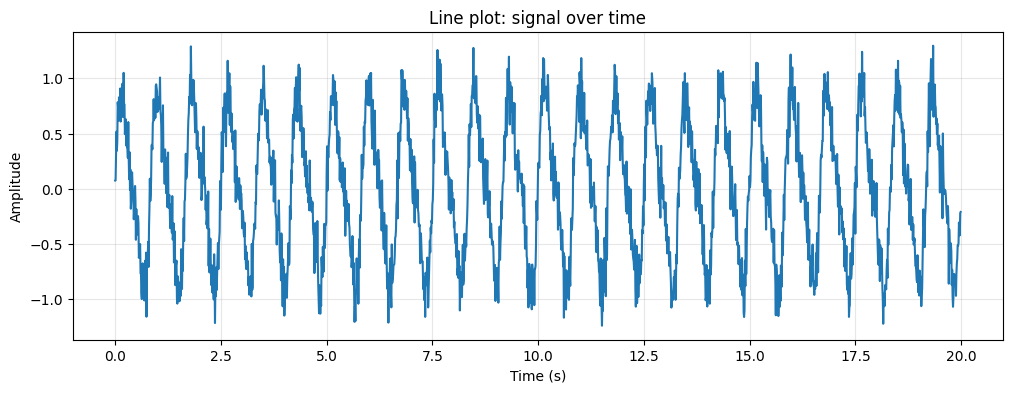

In [15]:
# Line plot: physiological signal over time

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Line plot: signal over time")
plt.grid(alpha=0.3)
plt.show()

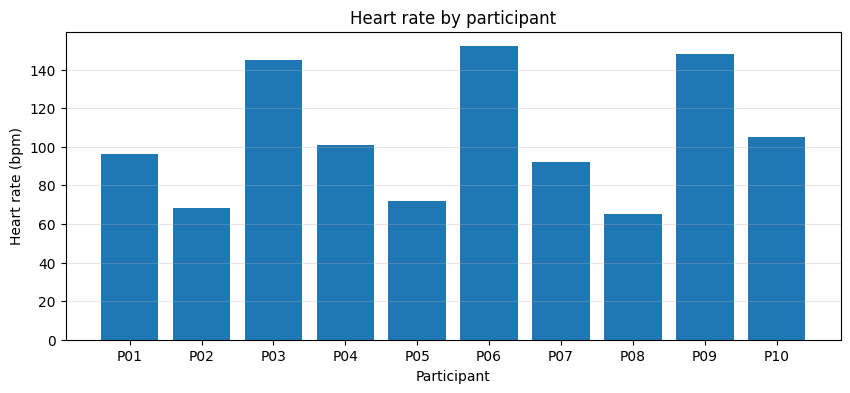

In [16]:
# Bar chart: heart rate by participant

plt.figure(figsize=(10, 4))
plt.bar(df["participant_id"], df["heart_rate"])
plt.xlabel("Participant")
plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate by participant")
plt.grid(axis="y", alpha=0.3)
plt.show()

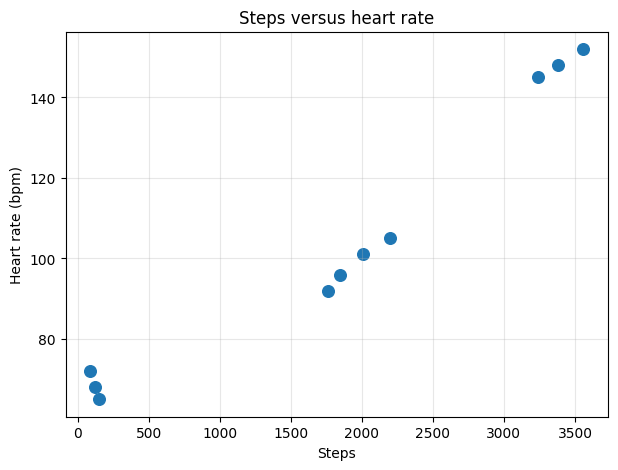

In [17]:
# Scatter plot: steps versus heart rate

plt.figure(figsize=(7, 5))
plt.scatter(df["steps"], df["heart_rate"], s=70)
plt.xlabel("Steps")
plt.ylabel("Heart rate (bpm)")
plt.title("Steps versus heart rate")
plt.grid(alpha=0.3)
plt.show()

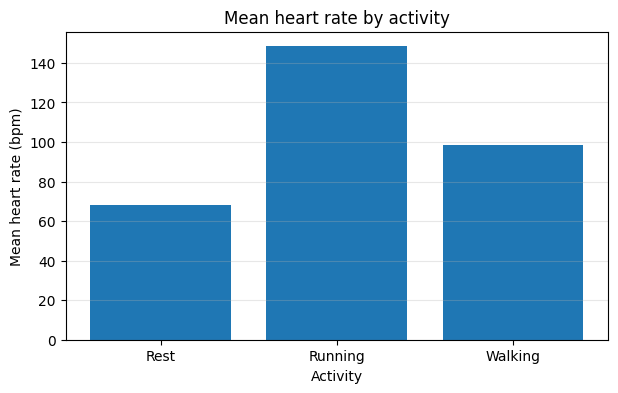

In [18]:
# Group comparison: mean heart rate by activity

mean_hr = df.groupby("activity")["heart_rate"].mean()

plt.figure(figsize=(7, 4))
plt.bar(mean_hr.index, mean_hr.values)
plt.xlabel("Activity")
plt.ylabel("Mean heart rate (bpm)")
plt.title("Mean heart rate by activity")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Good figure checklist

Before showing or submitting a figure, check:

- Does it answer a clear question?
- Is the title informative?
- Are axes labelled?
- Are units included when relevant?
- Is the scale appropriate?
- Is it readable?
- Is the interpretation written below the figure?

A figure without interpretation is usually incomplete.

# Where the other libraries fit later

You do **not** need to learn these today.

| Library/tool | We will use it for |
|---|---|
| SciPy | filtering and scientific computing |
| WFDB | reading PhysioNet waveform records |
| NeuroKit2 | ECG/EDA/respiration processing |
| tsfresh | automated time-series features |
| scikit-learn | basic predictive models |
| GitHub | collaboration and version control |
| Docker | reproducible deployment |

Today we only build the Python foundation.

# GitHub today — keep it simple

Today we only create the group workspace.

One group member should:

1. create a GitHub repository;
2. name it using the course format;
3. add a README;
4. add a Python `.gitignore`;
5. invite the other group members.

### Repository name

```text
HDS-F26-GroupXX-ProjectName
```

Example:

```text
HDS-F26-Group03-ECG-Signal-Quality
```

# Minimal README for today

Copy this into your repository:

```markdown
# Project title

## Group members
- Name
- Name
- Name

## Project topic
To be decided

## Dataset
To be decided

## Project status
Repository created in Lecture 1.
```

We will improve the repository structure and Git workflow later.

# Before you leave

You should have:

- [ ] run the lecture notebook cells;
- [ ] completed the two short in-class exercises;
- [ ] created or joined your group GitHub repository;
- [ ] added a minimal README;
- [ ] understood the difference between NumPy arrays and pandas DataFrames;
- [ ] created at least one line plot, bar chart and scatter plot.

### Take-home
Complete Assignment 1 notebook.

# Exercise 1 — NumPy and time series
## 30 minutes

Use the synthetic signal from today.

Tasks:

1. Print the number of samples, shape and data type.
2. Calculate minimum, maximum, mean and standard deviation.
3. Extract the interval from 5 to 10 seconds.
4. Plot the complete signal.
5. Plot only the 5–10 second interval.
6. Explain why the shorter plot may be useful.

### Deliverable
A notebook section with code, two figures and a short written answer.

In [ ]:
# Exercise 1 — NumPy and physiological time series

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Create a synthetic physiological signal
# --------------------------------------------------

np.random.seed(42)

fs = 100          # sampling frequency in Hz
duration = 20     # duration in seconds

time = np.arange(0, duration, 1/fs)

signal = (
    0.8 * np.sin(2 * np.pi * 1.2 * time)
    + 0.25 * np.sin(2 * np.pi * 2.4 * time)
    + 0.15 * np.random.randn(len(time))
)

print("Signal created successfully.")

In [ ]:
# --------------------------------------------------
# 2. Inspect the signal
# --------------------------------------------------

# TODO:
# Print:
# - number of samples
# - shape
# - data type
# - minimum
# - maximum
# - mean
# - standard deviation

print("Number of samples:", )
print("Shape:", )
print("Data type:", )

print("Minimum:", )
print("Maximum:", )
print("Mean:", )
print("Standard deviation:", )

In [ ]:
# --------------------------------------------------
# 3. Extract the interval from 5 to 10 seconds
# --------------------------------------------------

start_time = 5
stop_time = 10

# Convert time in seconds to sample indices
start_index = 
stop_index = 

# Extract signal and corresponding time values
signal_5_10 = 
time_5_10 = 

print("Start index:", start_index)
print("Stop index:", stop_index)
print("Number of extracted samples:", )

In [ ]:
# --------------------------------------------------
# 4. Plot the complete signal
# --------------------------------------------------

plt.figure(figsize=(12, 4))

# TODO: plot the signal


plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Complete physiological signal")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# --------------------------------------------------
# 5. Plot only the interval from 5 to 10 seconds
# --------------------------------------------------

plt.figure(figsize=(12, 4))

# TODO: plot time_5_10 and signal_5_10


plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Physiological signal from 5 to 10 seconds")
plt.grid(alpha=0.3)

plt.show()

### Interpretation

Why can looking at a shorter time interval sometimes be more useful than plotting the complete recording?

_Write 2–3 sentences here._

# Exercise 2 — pandas and visualisation
## 20–25 minutes

Use the wearable-health DataFrame.

Tasks:

1. Show the first five rows.
2. Report the number of rows and columns.
3. Find participants with heart rate > 100.
4. Calculate mean heart rate by activity.
5. Make a bar chart of mean heart rate by activity.
6. Make a scatter plot of steps versus heart rate.
7. Write two observations.

### Deliverable
A notebook section with one table, two figures and two written observations.

In [ ]:
# Exercise 2 — pandas and visualisation

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Create the wearable-health dataset
# --------------------------------------------------

data = {
    "participant_id": [
        "P01", "P02", "P03", "P04", "P05",
        "P06", "P07", "P08", "P09", "P10"
    ],

    "age": [
        24, 31, 28, 45, 52,
        37, 41, 29, 34, 48
    ],

    "sex": [
        "F", "M", "F", "M", "F",
        "M", "F", "M", "F", "M"
    ],

    "activity": [
        "Walking", "Rest", "Running", "Walking", "Rest",
        "Running", "Walking", "Rest", "Running", "Walking"
    ],

    "heart_rate": [
        96, 68, 145, 101, 72,
        152, 92, 65, 148, 105
    ],

    "steps": [
        1850, 120, 3240, 2010, 90,
        3560, 1760, 150, 3380, 2200
    ],

    "signal_quality": [
        0.95, 0.98, 0.82, 0.91, 0.97,
        0.76, 0.94, 0.96, 0.79, 0.89
    ]
}

df = pd.DataFrame(data)

df

In [ ]:
# --------------------------------------------------
# 2. Inspect the DataFrame
# --------------------------------------------------

# TODO:
# - display the first five rows
# - print the shape
# - print the column names
# - inspect data types

display()

print("Shape:", )
print("Columns:", )

# Data types:

In [ ]:
# --------------------------------------------------
# 3. Find participants with heart rate > 100 bpm
# --------------------------------------------------

high_hr = 

display(high_hr)

print("Number of participants:", )

In [ ]:
# --------------------------------------------------
# 4. Calculate mean heart rate by activity
# --------------------------------------------------

mean_hr_by_activity = 

display(mean_hr_by_activity)

In [ ]:
# --------------------------------------------------
# 5. Bar chart: mean heart rate by activity
# --------------------------------------------------

plt.figure(figsize=(7, 4))

# TODO: create a bar chart


plt.xlabel("Activity")
plt.ylabel("Mean heart rate (bpm)")
plt.title("Mean heart rate by activity")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# --------------------------------------------------
# 6. Scatter plot: steps versus heart rate
# --------------------------------------------------

plt.figure(figsize=(7, 5))

# TODO: create a scatter plot


plt.xlabel("Steps")
plt.ylabel("Heart rate (bpm)")
plt.title("Steps versus heart rate")
plt.grid(alpha=0.3)

plt.show()

### Observations

Write two observations based on your table and figures.

1. 
2. 

# Thank you!